### imports

In [1]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
from sklearn import neighbors
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
#import utils
#reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
#import seaborn as sns
#sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

/Users/finianashmead/miniconda3/envs/newmac1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np

In [3]:
import sys
print(sys.executable)

/Users/finianashmead/miniconda3/envs/newmac1/bin/python


In [4]:
import umapz2

In [5]:
df = pd.DataFrame({'col1':np.asarray([0.1, 0.2, 0.3]), 'col2':np.asarray([0.1, 0.3, 0.8])})

In [6]:
umapz2.calc_nmad(df['col1'], df['col2'])

0.11404615384615381

In [7]:
data = pd.read_parquet('som_umap_uncbudget_maps_260415.parquet')
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
spec95 = spec95[spec95['specz']>0.0]
spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOMrs0-1,SOMrs0-2,SOMrs1-1,SOMrs1-2,SOMrs2-1,SOMrs2-2,SOMrs3-1,SOMrs3-2,SOMrs4-1,SOMrs4-2,SOMrs5-1,SOMrs5-2,SOMrs6-1,SOMrs6-2,SOMrs7-1,SOMrs7-2,SOMrs8-1,SOMrs8-2,SOMrs9-1,SOMrs9-2,SOMrs10-1,SOMrs10-2,SOMrs11-1,SOMrs11-2,SOMrs12-1,SOMrs12-2,SOMrs13-1,SOMrs13-2,SOMrs14-1,SOMrs14-2,SOMrs15-1,SOMrs15-2,SOMrs16-1,SOMrs16-2,SOMrs17-1,SOMrs17-2,SOMrs18-1,SOMrs18-2,SOMrs19-1,SOMrs19-2,SOMrs20-1,SOMrs20-2,SOMrs21-1,SOMrs21-2,SOMrs22-1,SOMrs22-2,SOMrs23-1,SOMrs23-2,SOMrs24-1,SOMrs24-2,SOMrs25-1,SOMrs25-2,UMAPnn68-1,UMAPnn68-2,UMAPnn68-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn92-1,UMAPnn92-2,UMAPnn92-3
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,3,3,5,99,28,73,46,70,4,33,18,61,16,71,37,75,3,16,14,95,22,55,41,3,8,86,46,59,32,85,33,11,17,62,46,47,32,26,15,42,44,3,17,23,37,2,24,96,16,27,0,26,-2.187625,1.172747,0.019873,-2.010468,1.112640,0.093870,-1.927805,1.239550,0.143205
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,34,92,7,83,36,79,26,52,19,38,14,80,19,59,29,8,42,36,41,64,41,65,31,6,38,90,6,32,4,56,40,46,40,56,29,68,41,30,46,58,1,39,5,18,8,70,44,10,40,9,3,93,-1.057274,-0.347647,5.664723,-1.026085,-0.364025,5.754747,-1.012036,-0.245612,5.801317
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,29,43,31,6,20,20,34,33,43,54,0,39,1,43,21,40,13,82,12,11,18,74,20,76,20,0,31,83,28,22,27,94,38,21,22,14,40,77,29,17,22,72,46,62,37,23,14,39,2,70,30,54,6.897226,6.666687,2.855976,6.828689,6.606230,2.97

In [8]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

In [9]:
splits.keys()

dict_keys(['valid', 'train_lp', 'test_lp', 'train_spec', 'test_spec'])

In [10]:
#umapz2.plot_distributions(phot_df=data, spec_df=spec95, filename='distributions_260522.pdf')

In [11]:
with open("nearestz_errs_260727.pkl", "rb") as f:
    som_rm_errs = pickle.load(f)

with open("somz_errs_260727.pkl", "rb") as f:
    som_nrm_errs = pickle.load(f)

with open("umap_errs_260727.pkl", "rb") as f:
    umap_errs = pickle.load(f)

with open("colors_kNN_z_manhattan_errs_260513.pkl", "rb") as f:
    colors_errs = pickle.load(f)

### skip to here

In [12]:
with open("somz_binned_260727.pkl", "rb") as f:
    somtco_perf = pickle.load(f)

with open("nearestz_binned_260727.pkl", "rb") as f:
    somrm_perf = pickle.load(f)

with open("umap_binned_260727.pkl", "rb") as f:
    umap_perf = pickle.load(f)

with open("colors_binned_260513.pkl", "rb") as f:
    colors_perf = pickle.load(f)

In [13]:
with open("nearestz_errs_260727.pkl", "rb") as f:
    somrm_errs = pickle.load(f)

with open("somz_errs_260727.pkl", "rb") as f:
    somtco_errs = pickle.load(f)

with open("umap_errs_260727.pkl", "rb") as f:
    umap_errs = pickle.load(f)

with open("colors_kNN_z_manhattan_errs_260513.pkl", "rb") as f:
    colors_errs = pickle.load(f)

In [14]:
umap_errs.keys()

dict_keys(['outliers', 'nmads', 'biases', 'outliers_lp', 'nmads_lp', 'biases_lp'])

In [15]:
somrm_perf['LePHARE_trained']['f_outlier'].keys()

dict_keys(['mean', 'unc', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots'])

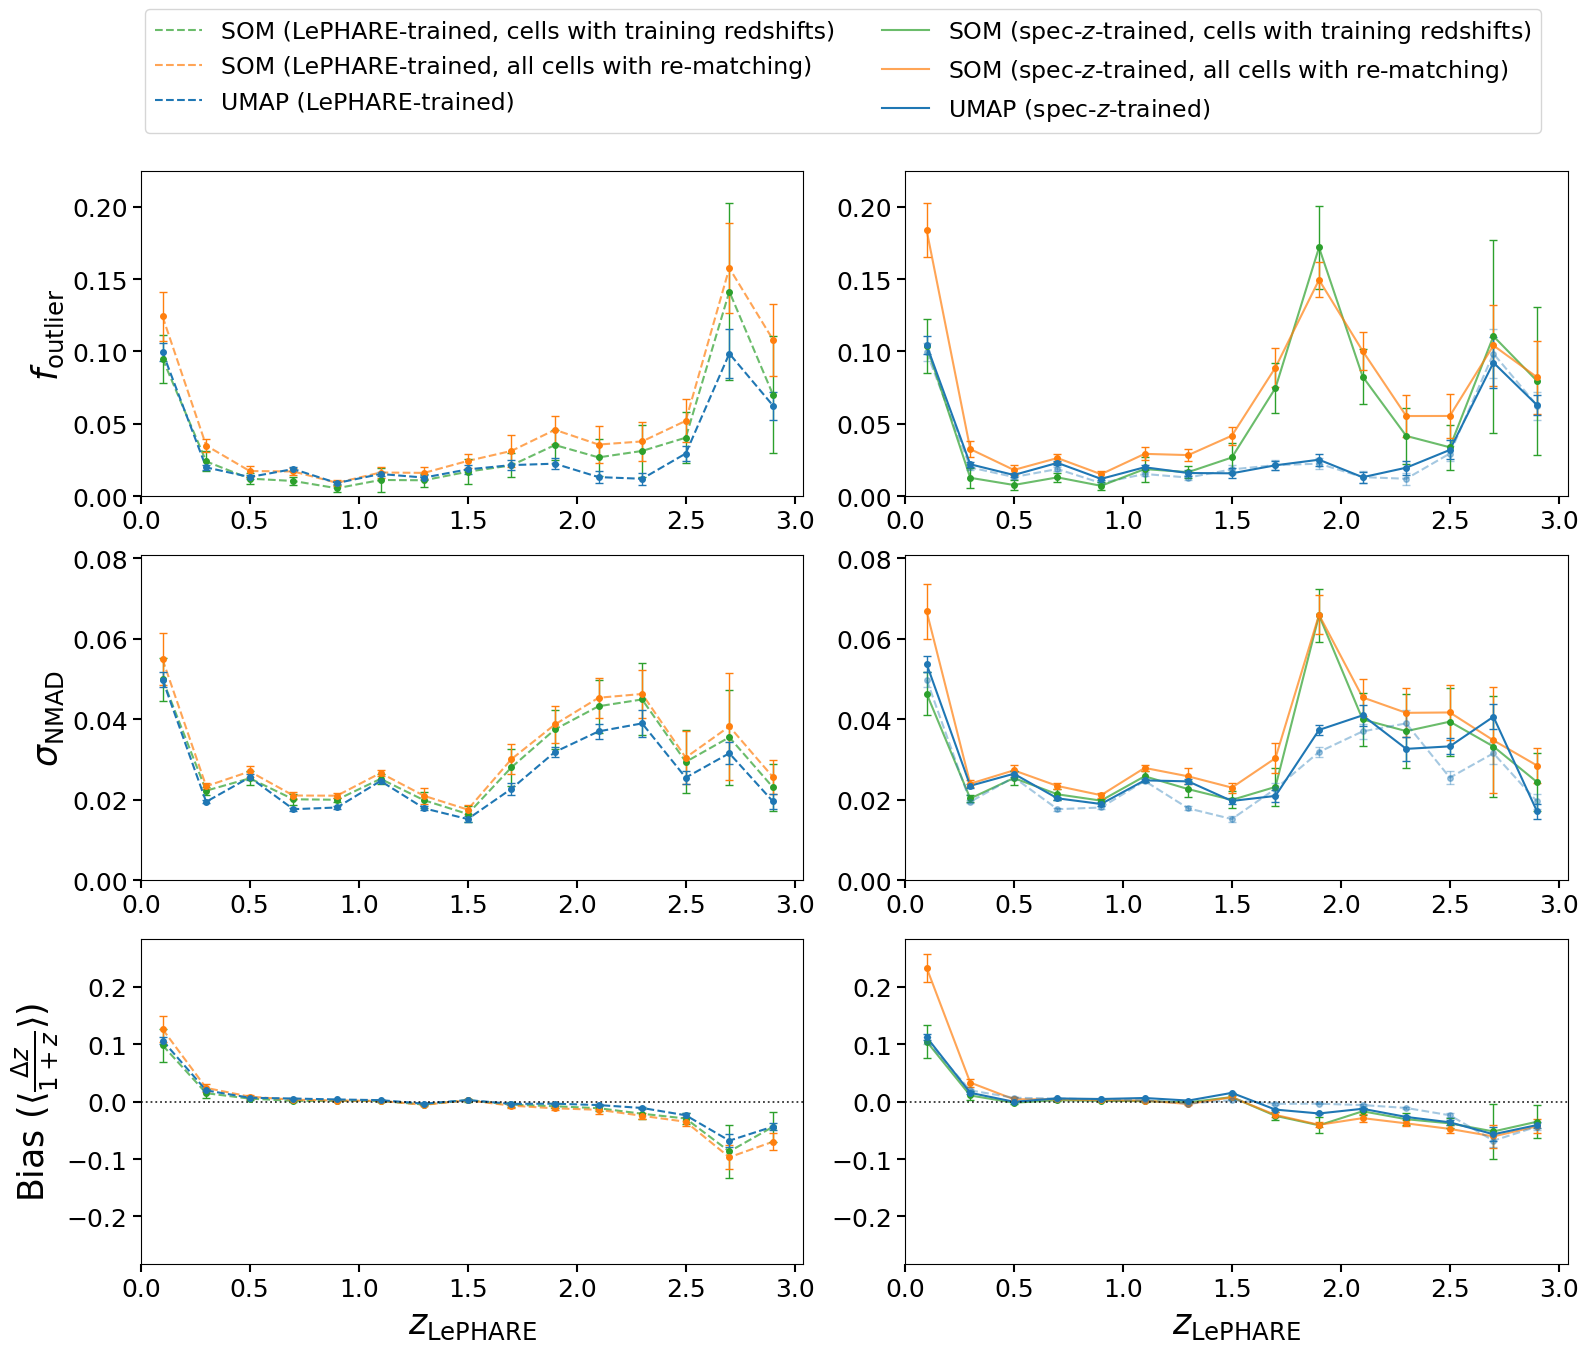

In [16]:
reload(umapz2)
umapz2.z_binned_stats3(somrm_perf=somrm_perf, somtco_perf=somtco_perf, umap_perf=umap_perf,
                       filename='zbinned_umap_vs_som_260727.pdf')

### sandplots

In [17]:
print(somrm_perf['specz_trained']['f_outlier'].keys())
print(somtco_perf['specz_trained']['f_outlier'].keys())
print(umap_perf['specz_trained']['f_outlier'].keys())
print(colors_perf['specz_trained']['f_outlier'].keys())

dict_keys(['mean', 'unc', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots'])
dict_keys(['mean', 'unc', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots'])
dict_keys(['mean', 'unc', 'unc_k', 'unc_nn', 'unc_rs', 'unc_boots'])
dict_keys(['f_outlier', 'unc_k', 'unc_boots'])


### Rachel plots

In [18]:
labels = ['finite test set', 'k-value choice']
cs = ['C1', 'C2']
unc_sources = ['boots', 'k']
ylims = [0.042, 0.014, 0.038]

In [19]:
umap_perf['specz_trained']['f_outlier']['unc_nn']

array([0.00181231, 0.00057239, 0.00081381, 0.00060446, 0.        ,
       0.        , 0.00039683, 0.00252893, 0.00116279, 0.00210526,
       0.002     , 0.003125  , 0.00351852, 0.01268074, 0.        ])

In [20]:
umap_perf['specz_trained']['f_outlier']['unc_boots']

array([0.00546734, 0.00157643, 0.00093684, 0.00113809, 0.00096741,
       0.00176276, 0.0015884 , 0.00236035, 0.00271228, 0.00299203,
       0.00270523, 0.00370464, 0.00550082, 0.01253526, 0.00675569])

In [21]:
colors_perf['specz_trained']['f_outlier']['unc_boots']

array([0.00490693, 0.00155533, 0.00097794, 0.0012765 , 0.0008275 ,
       0.00143927, 0.00130953, 0.00206178, 0.00337846, 0.00350949,
       0.00310643, 0.00507192, 0.00560352, 0.01260135, 0.00763025])

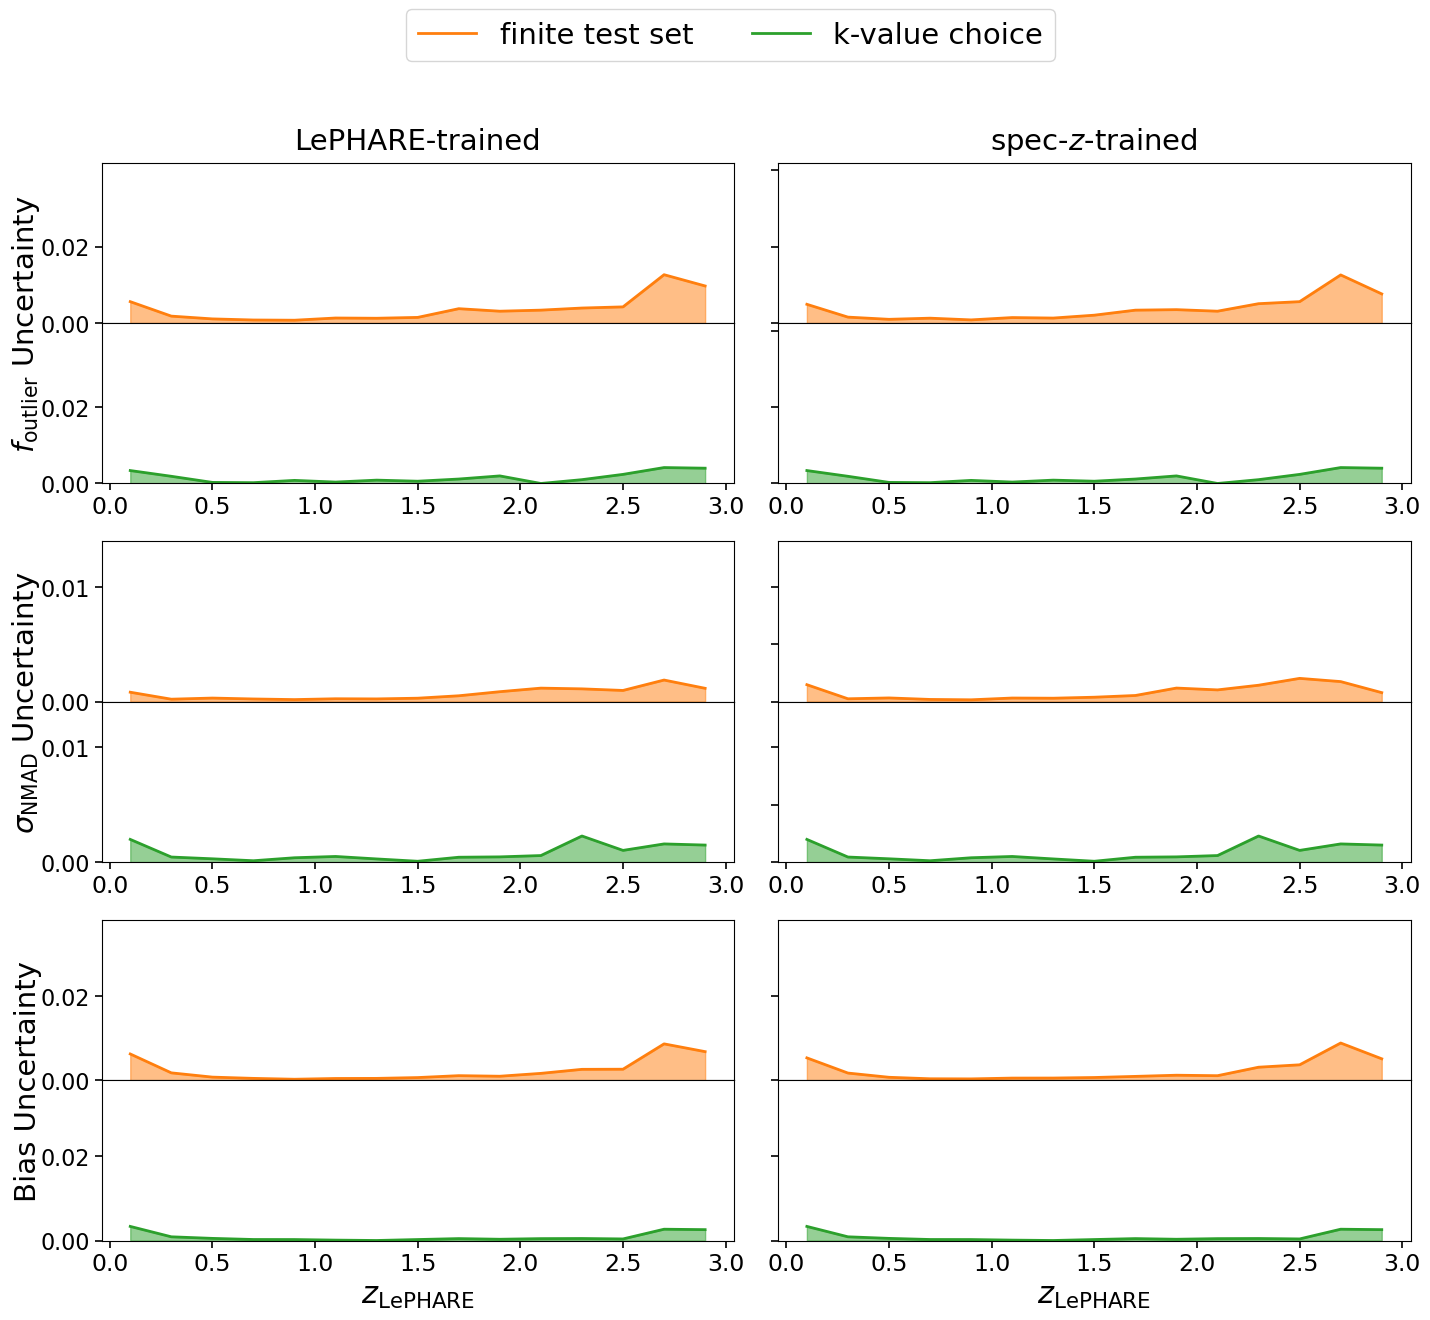

In [22]:
reload(umapz2)
umapz2.sandplot_split(uncs=colors_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='colors_uncs_260727.pdf')

In [23]:
#labels = ['embedding random seed','finite test set','size choice','sigma choice','learning_rate choice']
#cs = ['C0', 'C1', 'C2', 'C3', 'C4']
#unc_sources = ['rs', 'boots', 'size', 'sigma', 'learning_rate']

In [24]:
labels = ['embedding random seed', 'finite test set', 'k-value choice', 'n_neighbors choice']
cs = ['C0', 'C1', 'C2', 'C3']
unc_sources = ['rs', 'boots', 'k', 'nn']
ylims = [0.042, 0.014, 0.038]

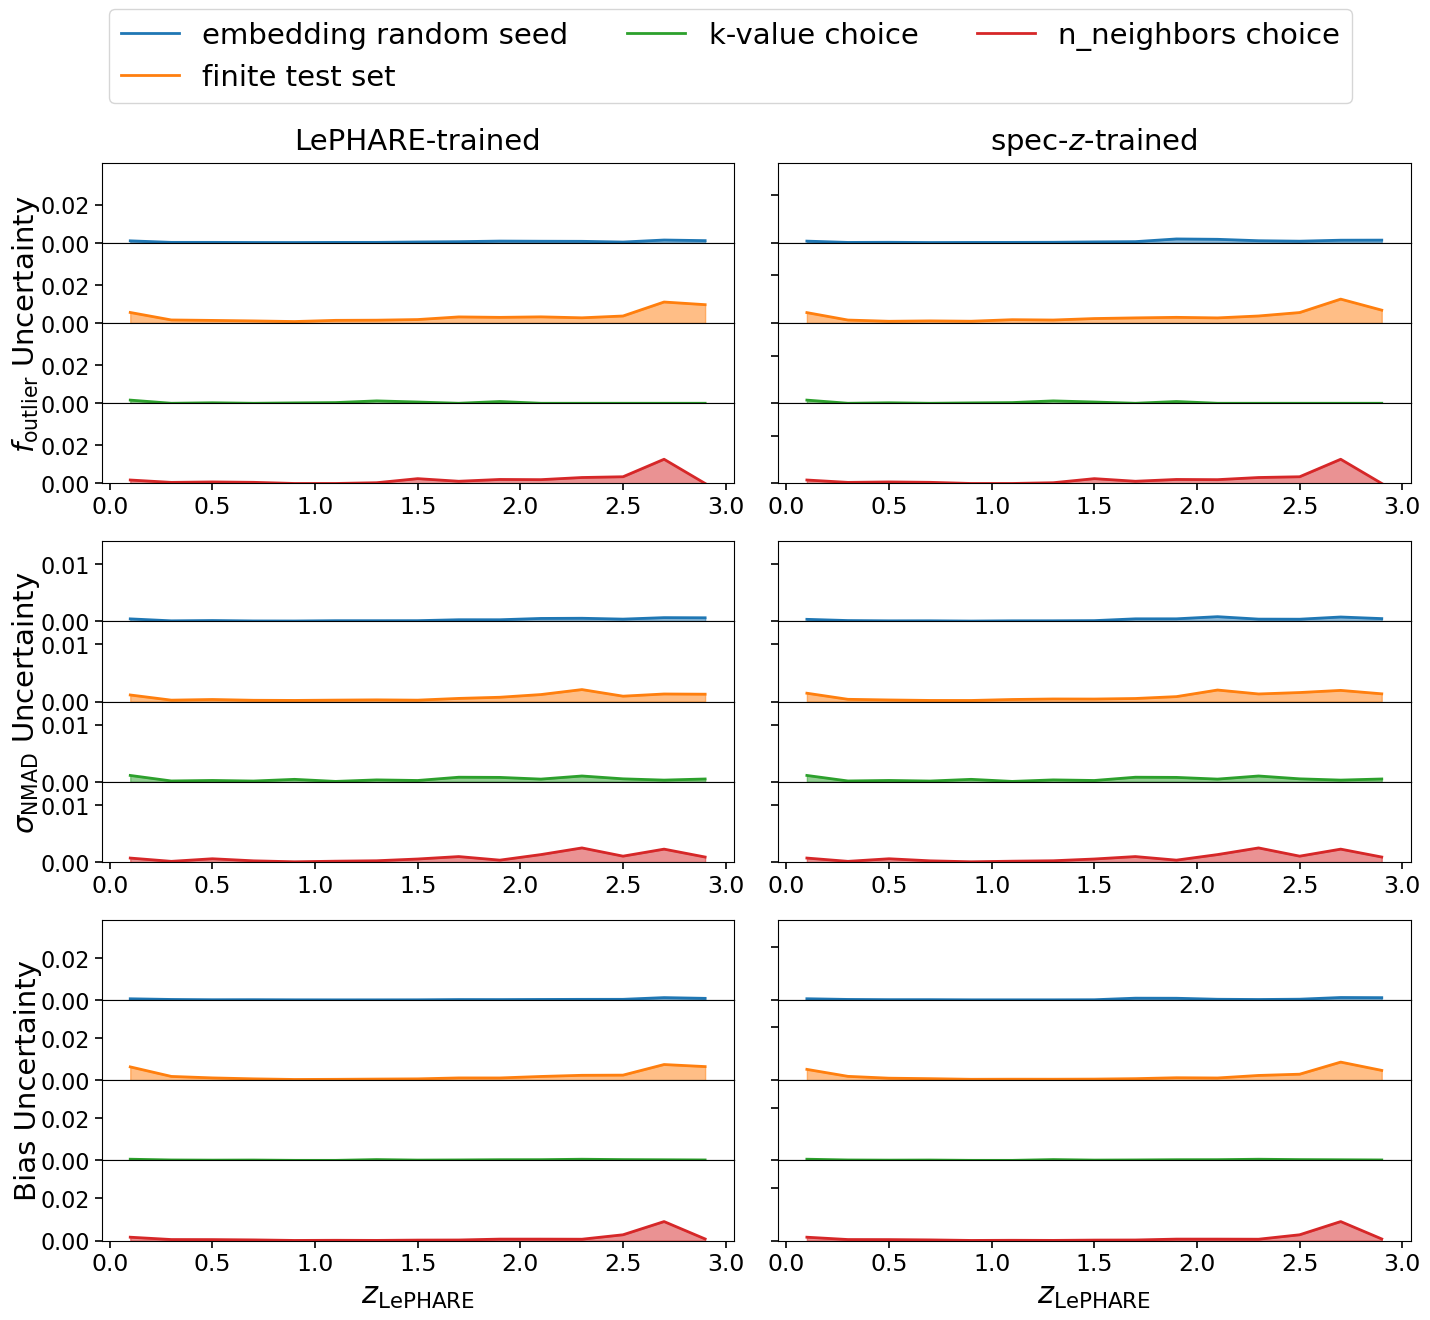

In [25]:
reload(umapz2)
umapz2.sandplot_split(uncs=umap_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='umap_uncs_260727.pdf')

In [26]:
train = 'LePHARE_trained'

In [27]:
umap_perf[train]['f_outlier']['unc_nn']

array([0.00181231, 0.00057239, 0.00081381, 0.00060446, 0.        ,
       0.        , 0.00039683, 0.00252893, 0.00116279, 0.00210526,
       0.002     , 0.003125  , 0.00351852, 0.01268074, 0.        ])

In [28]:
somrm_perf[train]['f_outlier']['unc_sigma']

array([0.010174  , 0.00072295, 0.00224212, 0.00105137, 0.00120119,
       0.00177929, 0.00128556, 0.00127937, 0.00648764, 0.00178818,
       0.00120697, 0.00322581, 0.0064777 , 0.01585498, 0.01550167])

In [29]:
somrm_perf[train]['f_outlier']['unc_learning_rate']

array([0.00942176, 0.00146851, 0.00223628, 0.00147377, 0.00101275,
       0.00248265, 0.00139532, 0.00244396, 0.00660403, 0.00107344,
       0.01110815, 0.00957661, 0.00539666, 0.01712213, 0.00934783])

In [30]:
somrm_perf[train]['f_outlier']['unc_size']

array([0.00670613, 0.00394574, 0.00132373, 0.00105066, 0.00081299,
       0.00138037, 0.00293893, 0.00265412, 0.00346405, 0.00671711,
       0.00079303, 0.00635081, 0.00931965, 0.00632876, 0.00819398])

In [31]:
labels = ['embedding random seed','finite test set','size choice','sigma choice','learning rate choice']
cs = ['C0', 'C1', 'C4', 'C5', 'C6']
unc_sources = ['rs', 'boots', 'size', 'sigma', 'learning_rate']
uncs = somrm_perf
ylims = [0.042, 0.014, 0.038]

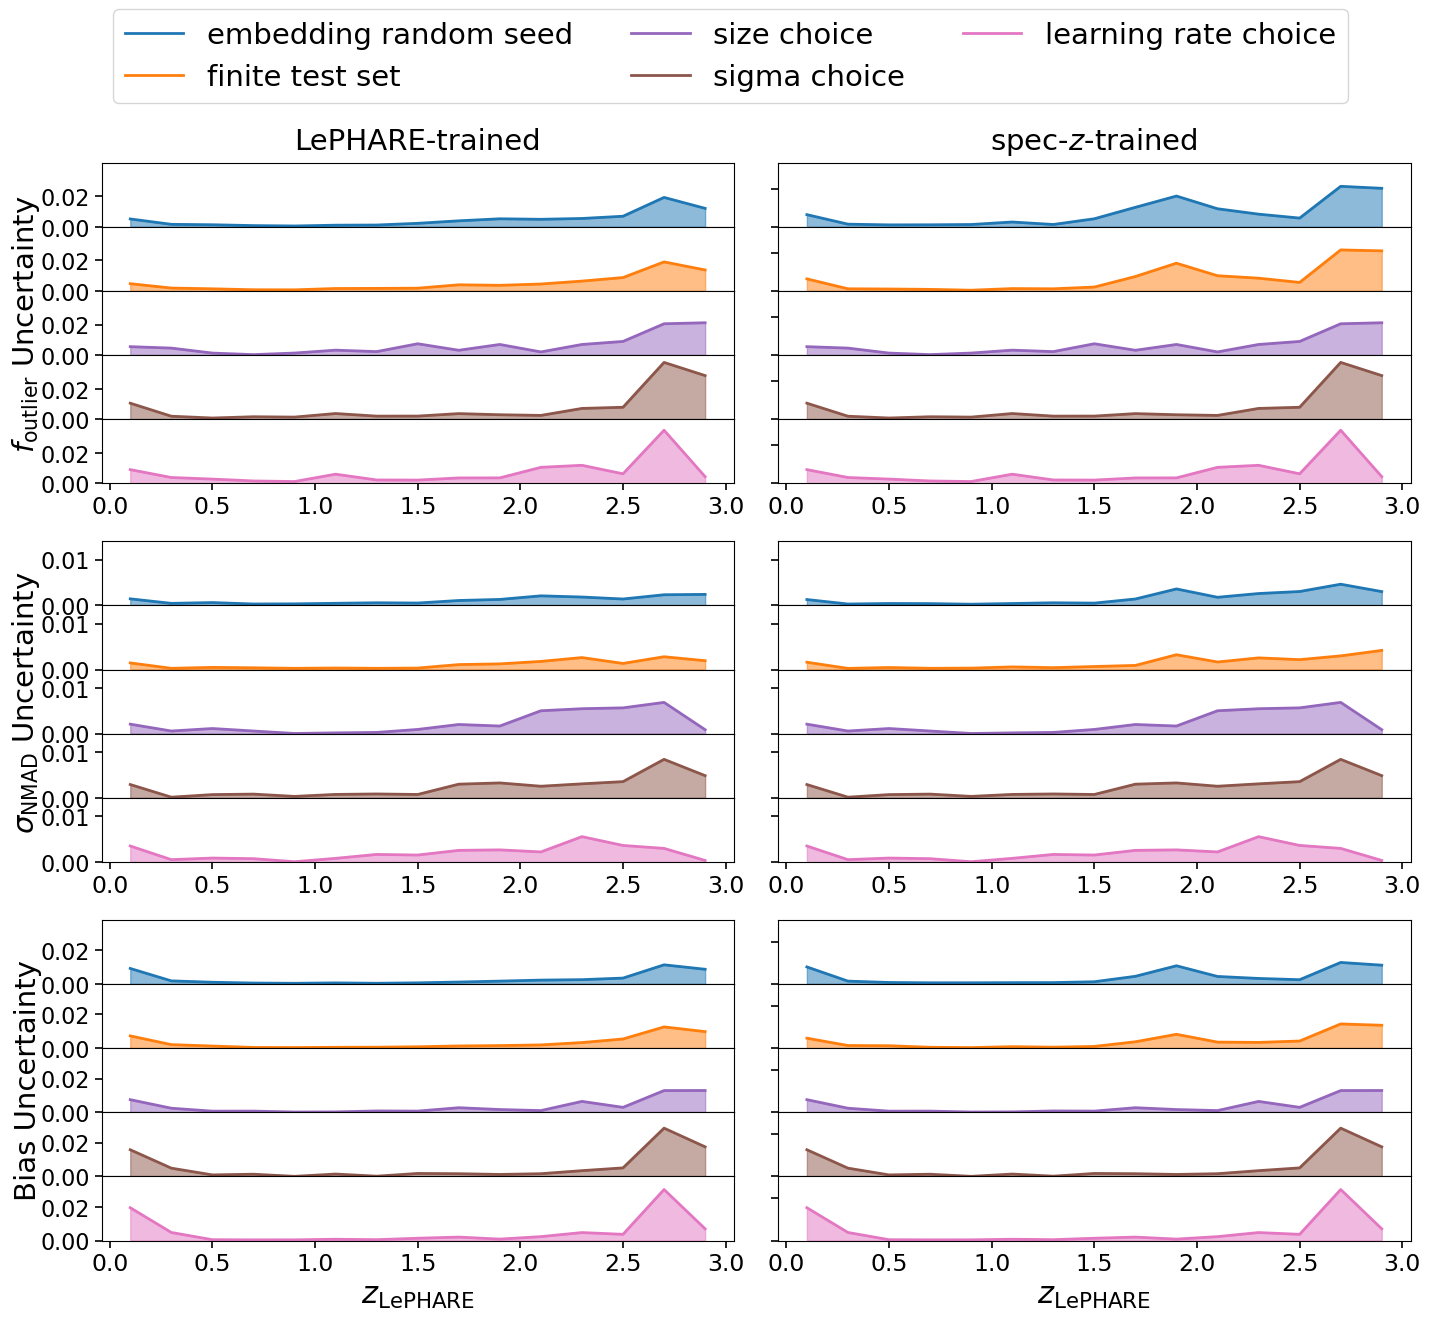

In [32]:
reload(umapz2)
umapz2.sandplot_split(uncs=somtco_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='somz_uncs_260727.pdf')

In [33]:
print('hi')

hi


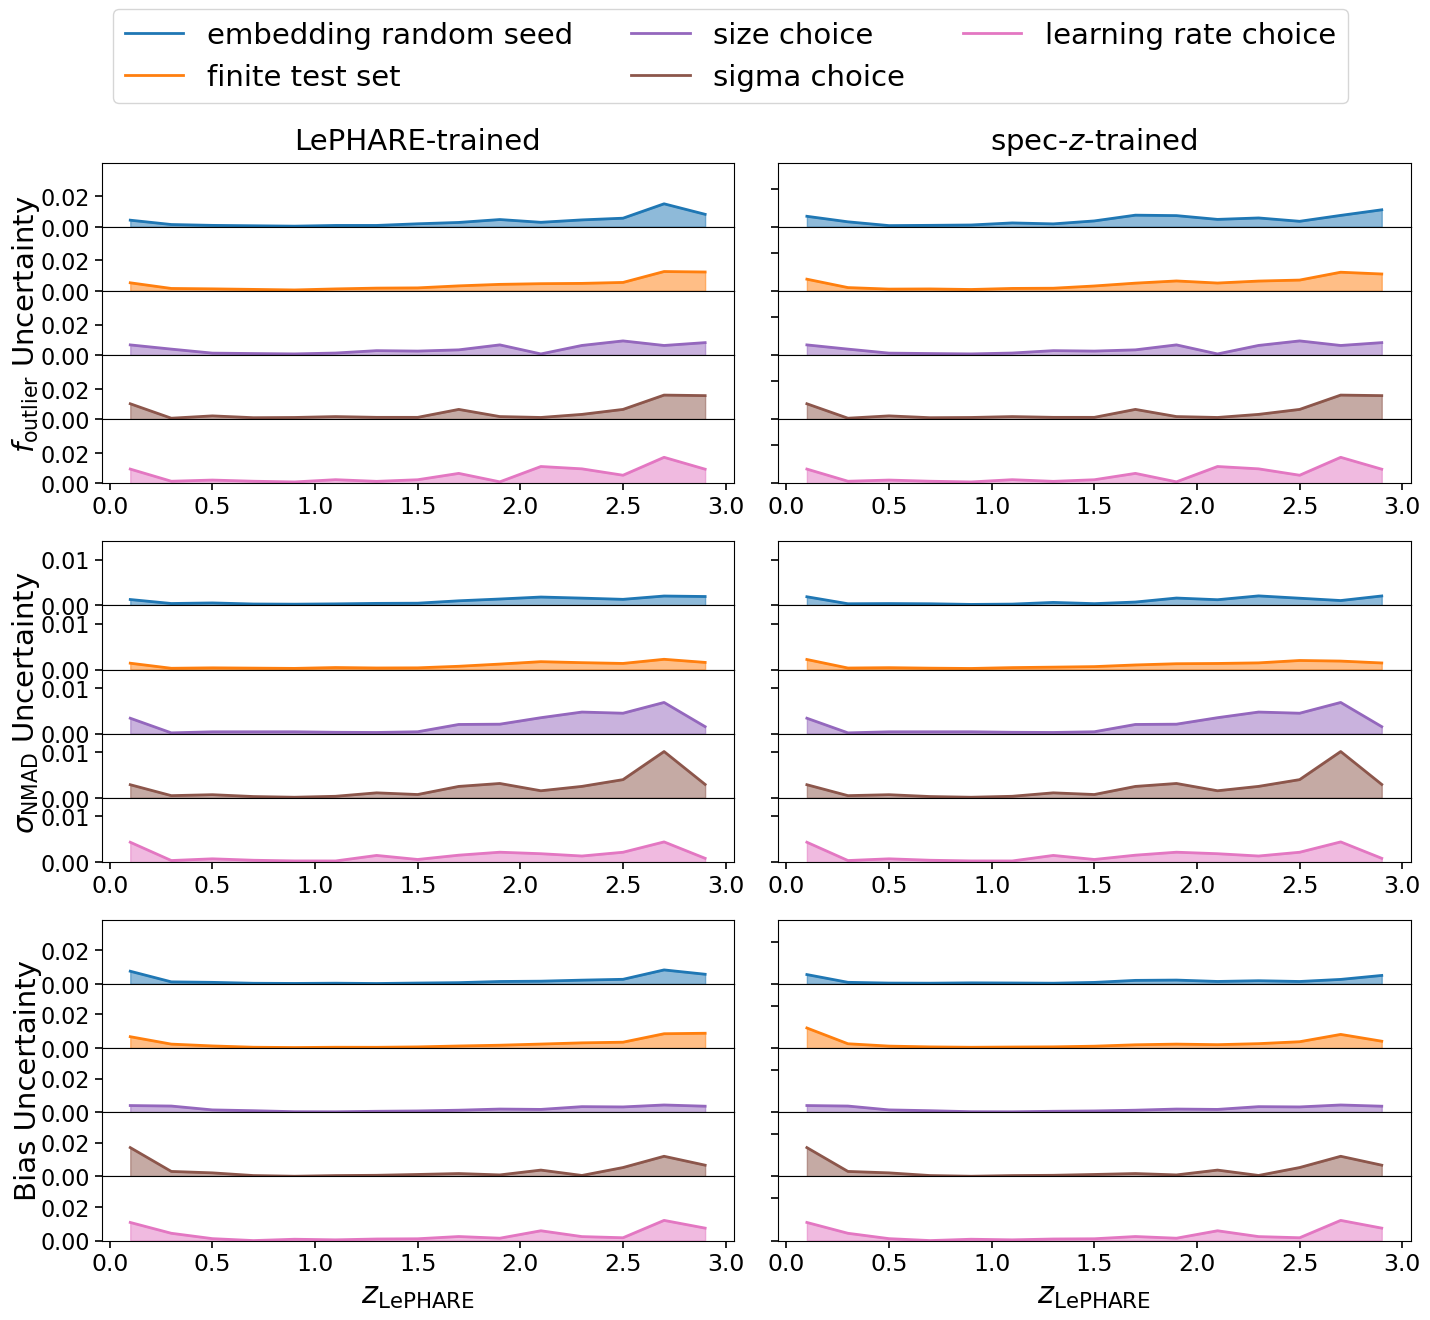

In [34]:
reload(umapz2)
umapz2.sandplot_split(uncs=somrm_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='nearestz_uncs_260727.pdf')

In [35]:
colors_errs

{'outliers': array([0.00596074, 0.00243963, 0.00101737, 0.00129403, 0.00115728,
        0.00148582, 0.0015748 , 0.00214501, 0.00357296, 0.00403013,
        0.00310643, 0.00516905, 0.00608838, 0.01327235, 0.00861514]),
 'nmads': array([0.00246901, 0.00050409, 0.00043055, 0.00022392, 0.0004082 ,
        0.00058101, 0.00040488, 0.00039268, 0.00068186, 0.00126861,
        0.00117186, 0.00268726, 0.00227146, 0.0023593 , 0.00167819]),
 'biases': array([0.00627502, 0.00192552, 0.00087751, 0.0004358 , 0.00040793,
        0.00051959, 0.00051725, 0.00069416, 0.00102919, 0.00122954,
        0.00117296, 0.00312393, 0.00367426, 0.00921942, 0.0057035 ]),
 'outliers_lp': array([0.00654543, 0.00261289, 0.00112442, 0.00082783, 0.00109823,
        0.00137145, 0.00153187, 0.00159443, 0.00393805, 0.00368313,
        0.00338179, 0.00405795, 0.00485783, 0.01332845, 0.01050265]),
 'nmads_lp': array([0.00214115, 0.00048755, 0.00042206, 0.00025966, 0.00041567,
        0.00054886, 0.00036225, 0.00030825, 0.0006

In [36]:
print('hi')

hi


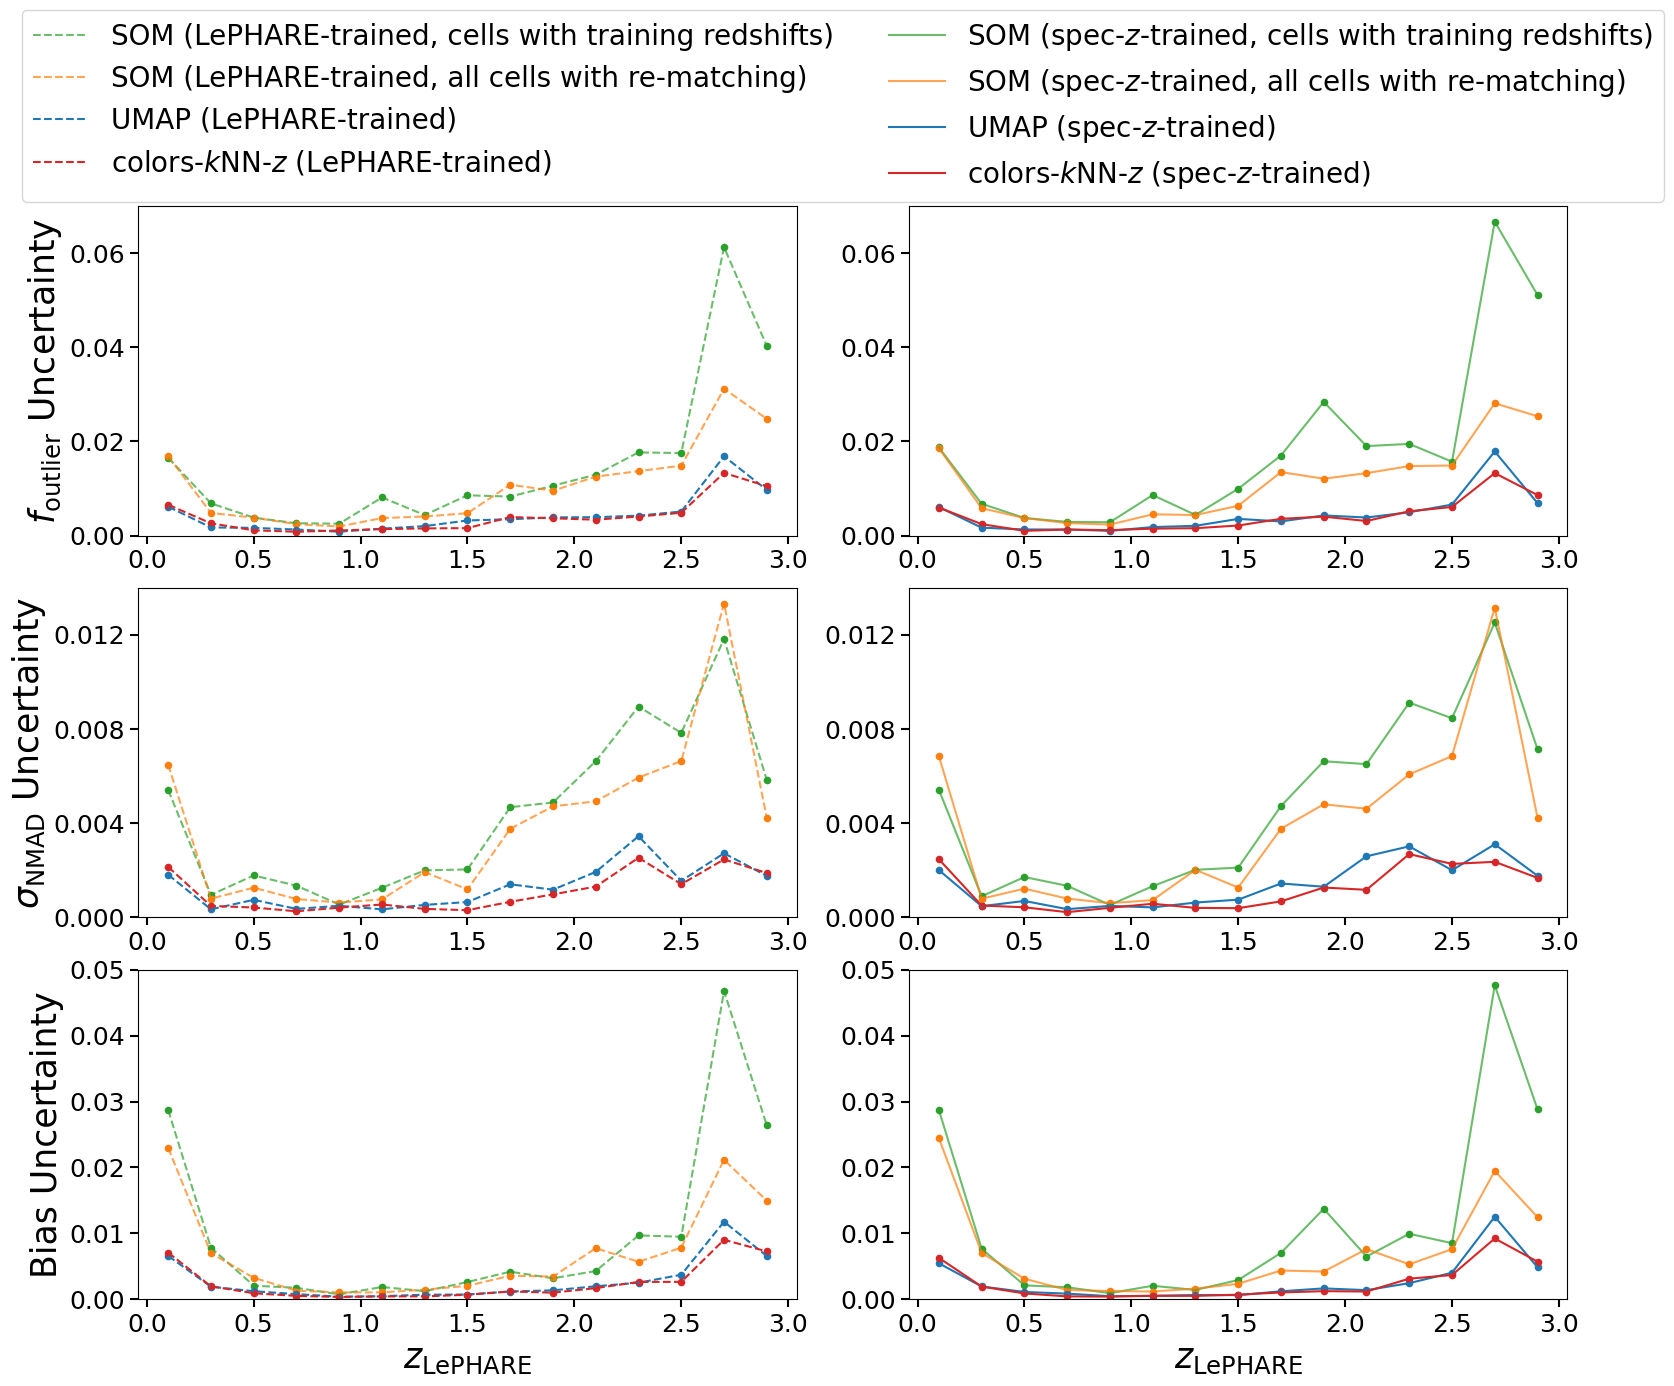

In [37]:
reload(umapz2)
umapz2.total_uncertainties(somrm_perf, somtco_perf, umap_perf, colors_perf=colors_errs, filename='total_uncertainties_260727.pdf')

### global

In [38]:
with open("global_results_260727.pkl", "rb") as f:
    global_results = pickle.load(f)

In [39]:
with open("highz_results_260727.pkl", "rb") as f:
    highz_results = pickle.load(f)

In [40]:
highz_results

{'LePHARE_trained': {'f_outlier': {'umap_value': 0.03770096200880482,
   'umap_unc': 0.0016145194961521784,
   'somrm_value': 0.05198434697537909,
   'somrm_unc': 0.0032288793565953514,
   'somtco_value': 0.03664726127961783,
   'somtco_unc': 0.003931543803437142,
   'colors_value': 0.03774661666394913,
   'colors_unc': 0.0017038407242859596},
  'nmad': {'umap_value': 0.028608223926217785,
   'umap_unc': 0.0005062016089367107,
   'somrm_value': 0.03340777146086828,
   'somrm_unc': 0.0007224536409295056,
   'somtco_value': 0.03151189508213393,
   'somtco_unc': 0.0008506891291912845,
   'colors_value': 0.02555118905599541,
   'colors_unc': 0.0005288108073644205},
  'bias': {'umap_value': -0.022839938224602622,
   'umap_unc': 0.0008870914536994832,
   'somrm_value': -0.026771356152547793,
   'somrm_unc': 0.0020943882196268362,
   'somtco_value': -0.01865434867955321,
   'somtco_unc': 0.0017922826787885866,
   'colors_value': -0.025065439871725097,
   'colors_unc': 0.0010079836830930574}},

In [41]:
highz_results['LePHARE_trained']['f_outlier']

{'umap_value': 0.03770096200880482,
 'umap_unc': 0.0016145194961521784,
 'somrm_value': 0.05198434697537909,
 'somrm_unc': 0.0032288793565953514,
 'somtco_value': 0.03664726127961783,
 'somtco_unc': 0.003931543803437142,
 'colors_value': 0.03774661666394913,
 'colors_unc': 0.0017038407242859596}

In [42]:
highz_results['LePHARE_trained']['nmad']

{'umap_value': 0.028608223926217785,
 'umap_unc': 0.0005062016089367107,
 'somrm_value': 0.03340777146086828,
 'somrm_unc': 0.0007224536409295056,
 'somtco_value': 0.03151189508213393,
 'somtco_unc': 0.0008506891291912845,
 'colors_value': 0.02555118905599541,
 'colors_unc': 0.0005288108073644205}

In [43]:
highz_results['LePHARE_trained']['bias']

{'umap_value': -0.022839938224602622,
 'umap_unc': 0.0008870914536994832,
 'somrm_value': -0.026771356152547793,
 'somrm_unc': 0.0020943882196268362,
 'somtco_value': -0.01865434867955321,
 'somtco_unc': 0.0017922826787885866,
 'colors_value': -0.025065439871725097,
 'colors_unc': 0.0010079836830930574}

### colors plot

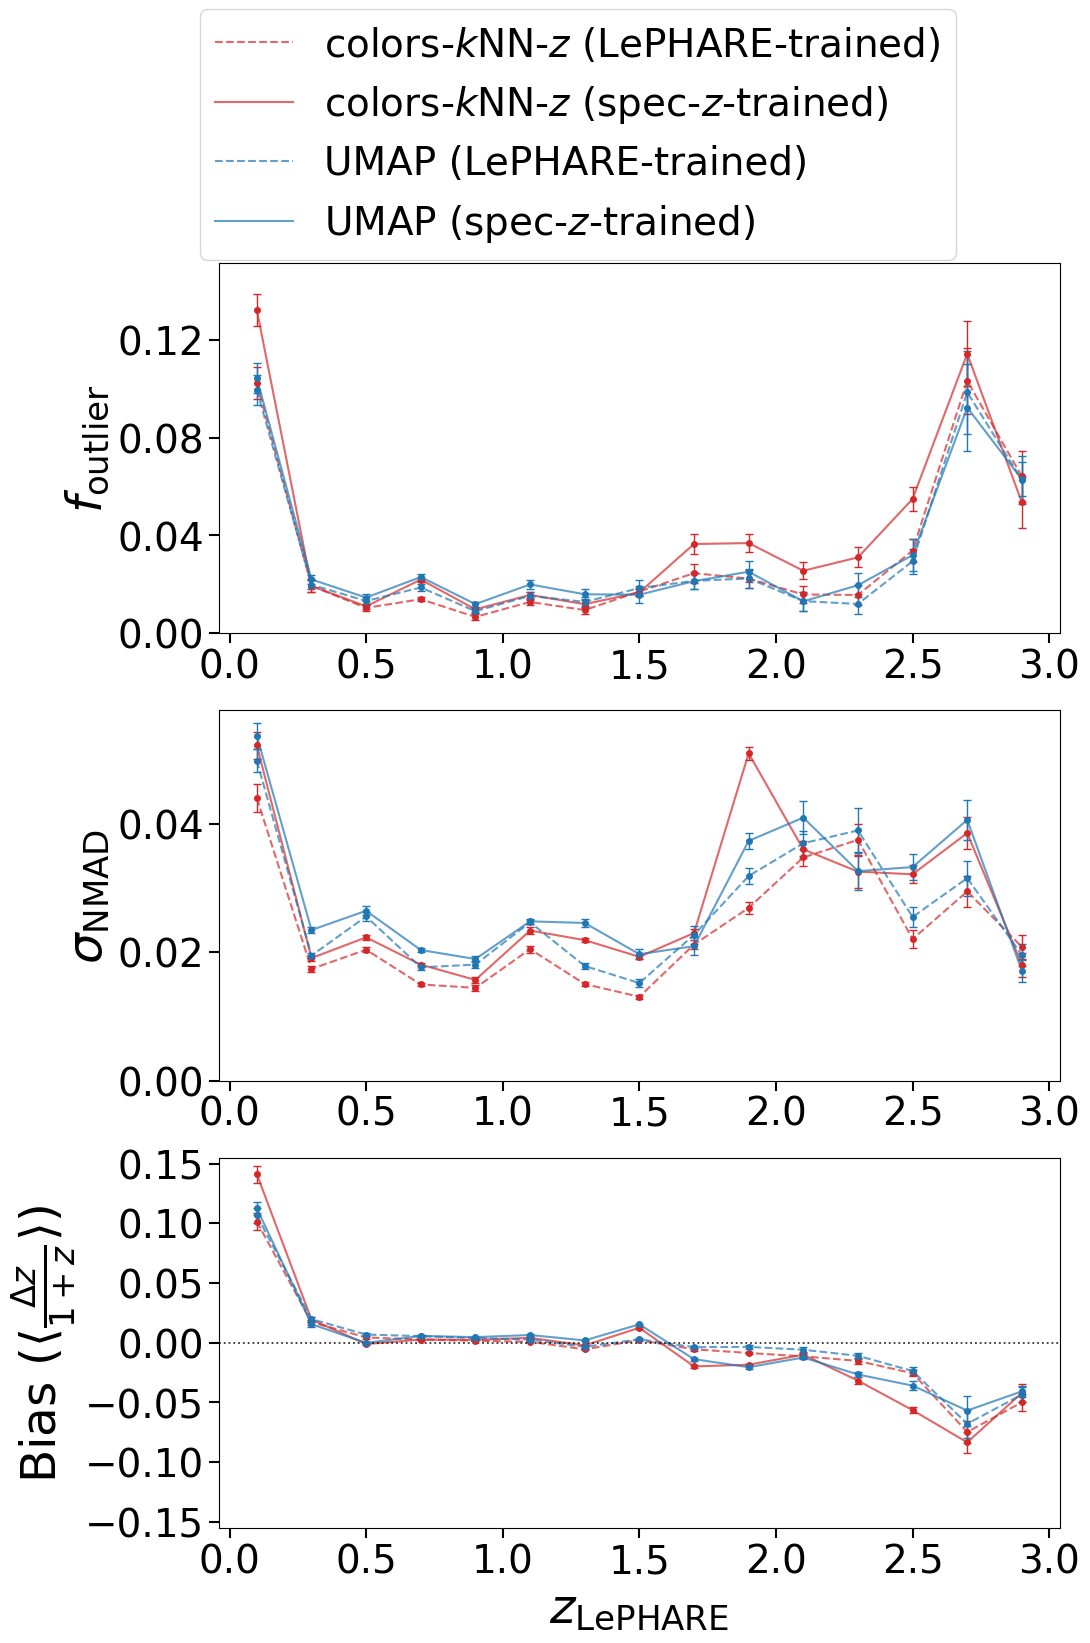

In [44]:
reload(umapz2)
umapz2.z_binned_umap_vs_colors2(umap_perf=umap_perf, colors_perf=colors_perf, 
                                umap_errs=umap_errs, colors_errs=colors_errs, filename='zbinned_vs_colors_260727.pdf')